# Natural Language Processing -  Data Science Portfolio - Mai Bui


# Introduction
The dataset used in this notebook was scraped (in November 2025 in a seperate script I wrote) from Letterboxd’s most popular reviews by week and includes the following variables: film title, release year, user rating, review date, and review text. Letterboxd is a social film-review platform that combines traditional rating systems with short-form, social-media-style commentary. Unlike professional film criticism, Letterboxd reviews are typically informal, highly expressive, and embedded in internet culture. Its user base is notably young. According to Cultured Magazine (2024), over half of Letterboxd’s audience is under 35 years old, and more than half of that group is between 16 and 24. As a result, the dominant linguistic style on the platform reflects Gen Z online communication norms, including heavy use of slang, sarcasm and irony, absurdist and deadpan humor, dense intertextual references to memes and internet culture, etc. This context is crucial when applying automated sentiment analysis, which is traditionally trained on more literal and formally structured language.

Sentiment analysis was conducted to evaluate how effectively a machine-learning model can interpret positivity and negativity in highly informal, sarcastic, and slang-heavy text. Most sentiment analysis models are built on datasets such as movie reviews, Twitter posts, or product reviews that often assume a relatively direct relationship between emotional words and emotional intent (Liu, 2012; Pang & Lee, 2008) . However, teen and Gen Z communication frequently violates this assumption. For example, phrases that appear negative on the surface (“this ruined my life”) may actually signal strong enjoyment, while positive words may be used sarcastically. This is especially relevant given that absurdist humor appears particularly common among younger audiences online (Partlow & Talarczyk, 2021). Absurdist humor, in particular, often decouples emotional tone from literal wording, making it difficult for traditional sentiment classifiers to correctly interpret intent.

This makes Letterboxd an especially valuable case study for testing the limits and biases of sentiment analysis in contemporary digital culture.

References
- Lee, S. (2024). Platforms Like Letterboxd Are Changing the Way We Watch Movies. But Are Studios Listening? Cultured Mag. https://www.culturedmag.com/article/2024/09/18/letterboxd-film-trend-box-office-gen-z/
- Partlow, C., & Talarczyk, P. (2021). Absurdism and Generation Z Humor: the Effects of Absurdist Content on Perceived Humor Levels in Generation Z Students. Journal of Student Research, 10(4). https://doi.org/10.47611/jsrhs.v10i4.2011

This notebook aims to accomplish two  goals:

1. Sentiment Analysis of Movie Reviews
Using VADER (Valence Aware Dictionary for sEntiment Reasoning), I want to see whether automated sentiment analysis capturing emotional intent in informal online language by looking at the most positive and negative reviews in the dataset and analyse the content. Besides that, I want to see whether sentiment aligns with numerical ratings (do users say what they rate? or is sentiment analysis correlated with how good or bad a person see a movie?)

2. Rating Classification Using Machine Learning
Using a Random Forest classifier, I want to see if we can predict how users will rate a film based solely on their written review. Also, I want to see if adding Sentiment Analysis help with the classification.


# Data preprocessing

In [4]:
import pandas as pd

df = pd.read_csv("datasets/nlp_dataset.csv")
df

,Title,Release Year,Rating,Review Date,Comment
0,Wicked: For Good,2025,★★★★★,10 Nov 2025,Elphaba and Fiyero will return in Dune: Part 3
1,Wicked: For Good,2025,★★★,07 Nov 2025,137 minutes of glinda and fiyero competing to ...
2,Wicked: For Good,2025,★★★★★,16 Nov 2025,That split screen shot of them separated by th...
3,Zootopia 2,2025,★★★½,25 Nov 2025,First time in 12 years I got fooled by a Disne...
4,Wicked: For Good,2025,★★★★,22 Nov 2025,the real villain was compulsory heterosexuality
...,...,...,...,...,...
1795,The Running Man,2025,★★★,23 Nov 2025,"""I'm still here, you shit-eaters.""\nWhen I fir..."
1796,Wicked: For Good,2025,★★★,26 Nov 2025,Oh they ummm huuuuh won't believe me if I tell...
1797,The Searchers,1956,★★★★½,24 Nov 2025,You can really tell John Ford influenced a lot...
1798,Hamnet,2025,NaN,20 Nov 2025,been watching movies my entire life and i’m st...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1800 non-null   object
 1   Release Year  1800 non-null   int64 
 2   Rating        1664 non-null   object
 3   Review Date   1800 non-null   object
 4   Comment       1800 non-null   object
dtypes: int64(1), object(4)
memory usage: 70.4+ KB


In [6]:
# Take english reviews only
# !pip install langdetect
from langdetect import detect, LangDetectException

def detect_language_safe(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["Comment"] = df["Comment"].astype(str)

df["language"] = df["Comment"].apply(detect_language_safe)
df = df[df["language"] == "en"].copy()

df

,Title,Release Year,Rating,Review Date,Comment,language
0,Wicked: For Good,2025,★★★★★,10 Nov 2025,Elphaba and Fiyero will return in Dune: Part 3,en
1,Wicked: For Good,2025,★★★,07 Nov 2025,137 minutes of glinda and fiyero competing to ...,en
2,Wicked: For Good,2025,★★★★★,16 Nov 2025,That split screen shot of them separated by th...,en
3,Zootopia 2,2025,★★★½,25 Nov 2025,First time in 12 years I got fooled by a Disne...,en
4,Wicked: For Good,2025,★★★★,22 Nov 2025,the real villain was compulsory heterosexuality,en
...,...,...,...,...,...,...
1795,The Running Man,2025,★★★,23 Nov 2025,"""I'm still here, you shit-eaters.""\nWhen I fir...",en
1796,Wicked: For Good,2025,★★★,26 Nov 2025,Oh they ummm huuuuh won't believe me if I tell...,en
1797,The Searchers,1956,★★★★½,24 Nov 2025,You can really tell John Ford influenced a lot...,en
1798,Hamnet,2025,NaN,20 Nov 2025,been watching movies my entire life and i’m st...,en


In [7]:
import re

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove hashtags (but keep the word following the hashtag)
    text = re.sub(r'#', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Remove additional white spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def case_normalization(text):
    return text.lower()

def tokenization(text):
    return text.split()

stopwordlist = set(['i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','no','nor','not','only','own','same','so','than','too','very','s','t','can','will','just','don','should','now'])
def remove_stopwords(tokens):
    return [token for token in tokens if token not in stopwordlist]



import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# function to get the POS tagging of tokens
def get_wordnet_pos(tag):
    if tag.startswith('J'):  
        return 'a'
    elif tag.startswith('V'):  
        return 'v'
    elif tag.startswith('N'):  
        return 'n'
    elif tag.startswith('R'):  
        return 'r'
    else:
        return 'n' 

def lemmatize(tokens):
    # Perform lemmatization
    pos_tagged_tokens = pos_tag(tokens)
    return [lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tagged_tokens]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/quynhmai/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [8]:
df['tokens'] = df['Comment'].apply(clean_text).apply(case_normalization).apply(tokenization).apply(remove_stopwords).apply(lemmatize)
df

,Title,Release Year,Rating,Review Date,Comment,language,tokens
0,Wicked: For Good,2025,★★★★★,10 Nov 2025,Elphaba and Fiyero will return in Dune: Part 3,en,"[elphaba, fiyero, return, dune, part]"
1,Wicked: For Good,2025,★★★,07 Nov 2025,137 minutes of glinda and fiyero competing to ...,en,"[minute, glinda, fiyero, compete, see, yearn, ..."
2,Wicked: For Good,2025,★★★★★,16 Nov 2025,That split screen shot of them separated by th...,en,"[split, screen, shot, separate, door, pure, evil]"
3,Zootopia 2,2025,★★★½,25 Nov 2025,First time in 12 years I got fooled by a Disne...,en,"[first, time, year, get, fooled, disney, twist..."
4,Wicked: For Good,2025,★★★★,22 Nov 2025,the real villain was compulsory heterosexuality,en,"[real, villain, compulsory, heterosexuality]"
...,...,...,...,...,...,...,...
1795,The Running Man,2025,★★★,23 Nov 2025,"""I'm still here, you shit-eaters.""\nWhen I fir...",en,"[im, still, shiteaters, first, heard, sure, id..."
1796,Wicked: For Good,2025,★★★,26 Nov 2025,Oh they ummm huuuuh won't believe me if I tell...,en,"[oh, ummm, huuuuh, wont, believe, tell, ahhhh,..."
1797,The Searchers,1956,★★★★½,24 Nov 2025,You can really tell John Ford influenced a lot...,en,"[really, tell, john, ford, influence, lot, dir..."
1798,Hamnet,2025,NaN,20 Nov 2025,been watching movies my entire life and i’m st...,en,"[watch, movie, entire, life, im, still, fascin..."


# Sentiment analysis with VADER

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#Create an instance of the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

#Define a function to perform sentiment analysis using VADER
def get_sentiment(text):
    sentiment = analyzer.polarity_scores(text)
    compound_score = sentiment['compound']
    return compound_score

df['sentiment'] = df['Comment'].apply(get_sentiment)
df

,Title,Release Year,Rating,Review Date,Comment,language,tokens,sentiment
0,Wicked: For Good,2025,★★★★★,10 Nov 2025,Elphaba and Fiyero will return in Dune: Part 3,en,"[elphaba, fiyero, return, dune, part]",0.0000
1,Wicked: For Good,2025,★★★,07 Nov 2025,137 minutes of glinda and fiyero competing to ...,en,"[minute, glinda, fiyero, compete, see, yearn, ...",0.0000
2,Wicked: For Good,2025,★★★★★,16 Nov 2025,That split screen shot of them separated by th...,en,"[split, screen, shot, separate, door, pure, evil]",-0.6597
3,Zootopia 2,2025,★★★½,25 Nov 2025,First time in 12 years I got fooled by a Disne...,en,"[first, time, year, get, fooled, disney, twist...",-0.6892
4,Wicked: For Good,2025,★★★★,22 Nov 2025,the real villain was compulsory heterosexuality,en,"[real, villain, compulsory, heterosexuality]",-0.5574
...,...,...,...,...,...,...,...,...
1795,The Running Man,2025,★★★,23 Nov 2025,"""I'm still here, you shit-eaters.""\nWhen I fir...",en,"[im, still, shiteaters, first, heard, sure, id...",0.4314
1796,Wicked: For Good,2025,★★★,26 Nov 2025,Oh they ummm huuuuh won't believe me if I tell...,en,"[oh, ummm, huuuuh, wont, believe, tell, ahhhh,...",-0.9022
1797,The Searchers,1956,★★★★½,24 Nov 2025,You can really tell John Ford influenced a lot...,en,"[really, tell, john, ford, influence, lot, dir...",0.0000
1798,Hamnet,2025,NaN,20 Nov 2025,been watching movies my entire life and i’m st...,en,"[watch, movie, entire, life, im, still, fascin...",0.7579


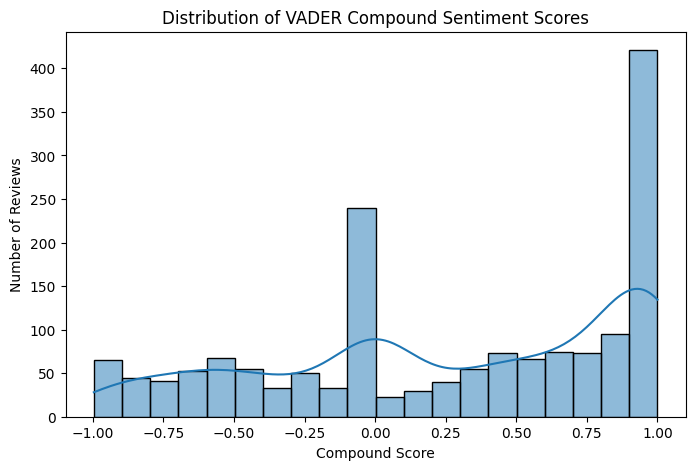

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['sentiment'], bins=20, kde=True)
plt.title("Distribution of VADER Compound Sentiment Scores")
plt.xlabel("Compound Score")
plt.ylabel("Number of Reviews")
plt.show()


In [11]:
df.loc[df['Title'] == 'Frankenstein'].iloc[0]

Title                                           Frankenstein
Release Year                                            2025
Rating                                                  ★★★★
Review Date                                      21 Oct 2025
Comment         Men want to give birth sooooo bad it’s crazy
language                                                  en
tokens          [men, want, give, birth, sooooo, bad, crazy]
sentiment                                            -0.6808
Name: 26, dtype: object

This is one example of how humour can be marked inaccurately by Sentiment Analysis tools.
Despite receiving a high rating of four stars, the sentiment analysis model classifies this review as strongly negative. From a human interpretive perspective, this comment is not expressing dissatisfaction with the film. Instead, it uses hyperbolic, ironic, and absurdist phrasing to make a humorous observation. This is an example of Gen Z–style internet humor that relies on exaggeration, sarcasm, and social commentary rather than literal emotional expression.
The misclassification can be explained by the presence of lexically negative or emotionally charged tokens such as “bad” “crazy” and the absence of explicitly positive affective terms (e.g., good, great, love)

This comment actually inspired this notebook because I looked at it and went: "I wonder what VADER would think about this." This is because it raised a question about the limitations of sentiment analysis. The observation sparked the central research question for this notebook: How do sentiment analysis tools interpret highly ironic, sarcastic, and absurdist humor common among younger audiences

## Most positive & negative review according to VADER

I wanted to see whether looking at the most positive and negative reviews may reveal in how sentiment analysis interprets humor, sarcasm, and absurdist expression among younger audiences.

In [12]:
# Most Negative Reviews
most_negative = df.sort_values('sentiment', ascending=True)[['Title', 'Rating', 'Review Date', 'Comment', 'sentiment']]
print("Most Negative Reviews:")

most_negative = most_negative.iloc[0]

print(f"{most_negative['Title']} | Rating: {most_negative['Rating']} | Review Date: {most_negative['Review Date']} | Sentiment: {most_negative['sentiment']:.3f}")
print(f"Comment: {most_negative['Comment']} \n")


Most Negative Reviews:
Frankenstein | Rating: ★★ | Review Date: 14 Oct 2025 | Sentiment: -0.997
Comment: Ponders none of the philosophical or moral issues of Shelley’s work, instead opting to go full steam ahead into Daddy Issues The Movie. Largely uncritical of male violence, instead absolving it because Daddy Issues. Painfully literal to the point that a character says to Victor’s face “You’re the monster.” Women are reduced to angels or demons. Has the gall to end with a Lord Byron quote. Oscar Isaac and Jacob Elordi are committed tho, finding madness and grace among all the CGI’d bullshit. 
ChiFilmFest #4

EDIT: I turned off the comments because people on here are unhinged. But to answer the  “what could the film do to be more critical of male violence” question — use filmic language better. All the death and violence in this film is shot like an action film or an epic, making the violence “thrilling” to watch, or in the case of the killing of the sailors renders it cartoonish. A c

Despite being a highly detailed review praising The Shining’s cinematic craftsmanship, VADER interprets it as extremely negative. A reason for this my be because of the use of words like “haunt,” “traumatic,” “abused,” “scares,” “horror,” and “controlling” are strongly associated with negative sentiment in the VADER lexicon. This in combination with the context of the review, of how emotionally charged words are used to emphasise the praise, VADER treats those words as indicators of negativity, even if they are used to praise the film. As such  A highly positive human evaluation is misclassified as negative, showing the mismatch between literal word polarity and actual intent. This demonstrate how  sentiment analysis may systematically fail on expert-level or nuanced reviews, even when the text is literally positive in intent. While this does not reveal much about how internet "lingo" is lost with VADER, it shows how even more 'normal' reviews and text can be incorrectly scored.

In [13]:

# Most Positive Reviews
most_positive = df.sort_values('sentiment', ascending=False)[['Title', 'Rating', 'Review Date', 'Comment', 'sentiment']]
print("Most Positive Reviews:")

most_positive = most_positive.iloc[0]
print(f"{most_positive['Title']} | Rating: {most_positive['Rating']} | Review Date: {most_positive['Review Date']} | Sentiment: {most_positive['sentiment']:.3f}")
print(f"Comment: {most_positive['Comment']}")


Most Positive Reviews:
Wake Up Dead Man | Rating: ★★★★★ | Review Date: 30 Nov 2025 | Sentiment: 1.000
Comment: "That poor girl."
“Start fighting wolves, and before you know it, everyone you don’t understand is a wolf.”
"I have to do it of my own free will, or it won't mean anything."
As a former youth group kid, Rian Johnson’s Knives Out movies have always been, whether implicitly or explicitly, about God.
It started with the lightning-in-the-bottle of the first movie: a film already chock-full of references to Johnson's evangelical childhood, from a 90s Christian rock needledrop in the background of a bar scene to the name of Chris Evans' character Ransom, inspired by CS Lewis's Space Trilogy. But these undercurrents go deeper than being simply (as Blanc might say) ornamental. The very eschatology of Knives Out's climactic ending comeuppance is one of the upside down kingdom of Christ: the last shall be first, and the meek and lowly shall inherit and dwell in the House of God with the

This review is extremely long and complex, weaving together themes of religion, morality, and narrative interpretation. It’s full of irony, references, and abstract discussion about faith, God, and cinematic storytelling. Vader may have scored it positively due to many explicitly positive words (“good,” “benevolent,” “touched,” “heart-rending,” “profundity,” “truth”). Even when discussing criticism or wrongdoing, the overall framing emphasizes moral or spiritual resolution, which VADER interprets as positive. Even though, the score aligns more with the human rating, it highlights a limitation of this method as it cannot capture the nuance and content and just sums up polarity words. Although technically correct, the score simplifies a deeply layered review, showing that sentiment analysis can give the “right” polarity while missing almost everything about meaning, humor, or irony.

In [14]:
import numpy as np
# -- Convert star ratings to numeric so that we can compute averages -- 
def stars_to_num(s):
    if pd.isna(s):
        return np.nan
    full_stars = s.count("★")
    half_star = "½" in s
    return full_stars + (0.5 if half_star else 0)

df["Rating_numeric"] = df["Rating"].apply(stars_to_num)

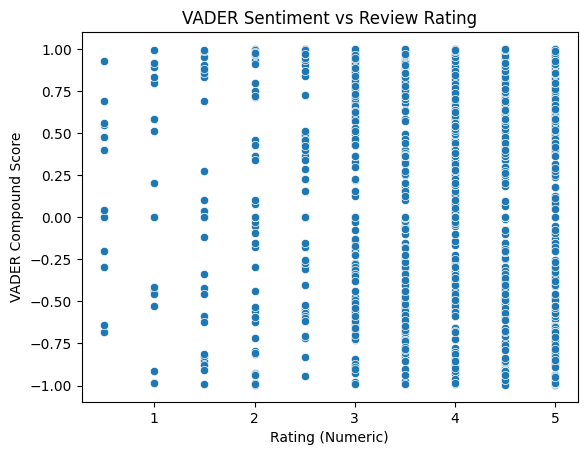

0.08831034967966622


In [15]:
sns.scatterplot(x='Rating_numeric', y='sentiment', data=df)
plt.title("VADER Sentiment vs Review Rating")
plt.xlabel("Rating (Numeric)")
plt.ylabel("VADER Compound Score")
plt.show()

print(df['Rating_numeric'].corr(df['sentiment']))


There seem to be little correlation between Sentiment Score and Rating. This can be either from user side and/or because of VADER
- Users may give a film 5 stars while writing a review filled with negative-seeming language (sarcasm, irony, absurdist humor), or conversely, rate a film poorly while using emotionally positive words to describe memorable moments or performances. Also they may provide a review text that serve a different purpose than ratings.
- VADER relies on a dictionary of words with pre-assigned sentiment scores, so it struggles with sarcasm and irony, absurdist humour, and context-dependent slang.

=> Even if a user genuinely enjoys a film, VADER’s output may fail to align with human judgment, especially for sarcasm, irony, or absurdist humor, which may explain the weak correlation between review text sentiment and star ratings.


# Classifying

In [16]:
df

,Title,Release Year,Rating,Review Date,Comment,language,tokens,sentiment,Rating_numeric
0,Wicked: For Good,2025,★★★★★,10 Nov 2025,Elphaba and Fiyero will return in Dune: Part 3,en,"[elphaba, fiyero, return, dune, part]",0.0000,5.0
1,Wicked: For Good,2025,★★★,07 Nov 2025,137 minutes of glinda and fiyero competing to ...,en,"[minute, glinda, fiyero, compete, see, yearn, ...",0.0000,3.0
2,Wicked: For Good,2025,★★★★★,16 Nov 2025,That split screen shot of them separated by th...,en,"[split, screen, shot, separate, door, pure, evil]",-0.6597,5.0
3,Zootopia 2,2025,★★★½,25 Nov 2025,First time in 12 years I got fooled by a Disne...,en,"[first, time, year, get, fooled, disney, twist...",-0.6892,3.5
4,Wicked: For Good,2025,★★★★,22 Nov 2025,the real villain was compulsory heterosexuality,en,"[real, villain, compulsory, heterosexuality]",-0.5574,4.0
...,...,...,...,...,...,...,...,...,...
1795,The Running Man,2025,★★★,23 Nov 2025,"""I'm still here, you shit-eaters.""\nWhen I fir...",en,"[im, still, shiteaters, first, heard, sure, id...",0.4314,3.0
1796,Wicked: For Good,2025,★★★,26 Nov 2025,Oh they ummm huuuuh won't believe me if I tell...,en,"[oh, ummm, huuuuh, wont, believe, tell, ahhhh,...",-0.9022,3.0
1797,The Searchers,1956,★★★★½,24 Nov 2025,You can really tell John Ford influenced a lot...,en,"[really, tell, john, ford, influence, lot, dir...",0.0000,4.5
1798,Hamnet,2025,NaN,20 Nov 2025,been watching movies my entire life and i’m st...,en,"[watch, movie, entire, life, im, still, fascin...",0.7579,NaN


## [TEST] Classifying using each rating as a class using RandomForestClassifier

In [17]:
df = df.dropna(subset=['Rating_numeric']).reset_index(drop=True)

df['rating_class'] = df['Rating_numeric'].astype(str)  # e.g., '4.0', '4.5', '5.0'


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the dataset into training and testing sets
# The text is what we use to try to predict the device. 
# For time-purposes, we use only a subset of the data. Feel free to set subset to 42512 (full dataset) to train a more accurate model
# Make sure before submitting to CodeGrade to set subset back to 15000, as the process might otherwise time out.
X_train, X_test, y_train, y_test = train_test_split(df['Comment'], df['rating_class'], test_size=0.3, random_state=42)

# Vectorize the text messages into a bag-of-words model
vectorizer = CountVectorizer(stop_words='english') # Drop stopwords in English
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)


# Use a machine learning classifier, in this case, a Random Forest
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_vectorized, y_train)

# Predict the device used for the test set
predictions = classifier.predict(X_test_vectorized)



In [19]:

##### The rest is printing and evaluation ####

# Evaluate the classifier
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))


              precision    recall  f1-score   support

         0.5       0.00      0.00      0.00         4
         1.0       0.00      0.00      0.00         9
         1.5       0.00      0.00      0.00         6
         2.0       0.00      0.00      0.00        15
         2.5       0.00      0.00      0.00        22
         3.0       0.33      0.07      0.12        56
         3.5       0.33      0.11      0.17        54
         4.0       0.25      0.46      0.32       111
         4.5       0.22      0.19      0.20        79
         5.0       0.21      0.31      0.25        97

    accuracy                           0.23       453
   macro avg       0.13      0.11      0.11       453
weighted avg       0.22      0.23      0.20       453

Accuracy: 0.23399558498896247


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Initial Classification Attempt: Predicting Exact Ratings (Failed)

I attempted to predict the exact numerical rating (0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0) based solely on review text. The Random Forest classifier achieved only 25% accuracy, which is barely better than random guessing.

This may be because of an imbalance of data for each predictor, and in some classes, there is too little data (not enough, less than 30?)


In [20]:
df["Rating_numeric"].value_counts()

Rating_numeric
4.0    359
5.0    324
4.5    274
3.5    198
3.0    172
2.5     68
2.0     53
1.5     28
1.0     19
0.5     12
Name: count, dtype: int64


Another reason may be because the difference between a 4.0-star and 4.5-star review is subjective and subtle, which can be hard to distinguish  based on text alone. Also, the words used to describe things that separate "very good" from "excellent" are different and inconsistent across users.

To address the aforementioned shortcoming of the imbalance in class from the dataset, a binary classification (High vs. Low Ratings) maybe better. It addresses the imbalance by collapsing 10 classes into 2 for more balanced groups. Also the language distinguishing "bad" from "good" may be stronger, enough for a better prediction.

## Classifying by dividing "high" and "low" rating using RandomForestClassifier

In [21]:
# Drop rows where Rating_numeric is NaN
df = df.dropna(subset=['Rating_numeric']).reset_index(drop=True)


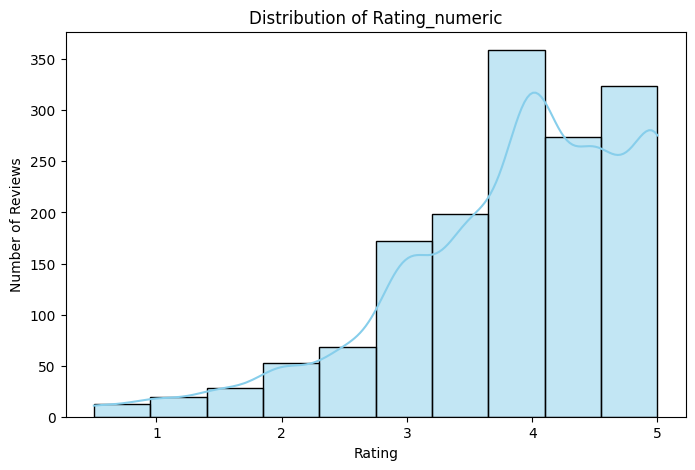

4.0

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Rating_numeric"], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Rating_numeric")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

df["Rating_numeric"].median()

Because the median is 4, it will be our cutoff.

In [23]:
# High ratings = 4 stars or more
df['rating_class'] = df['Rating_numeric'].apply(lambda x: 1 if x >= 4 else 0)

In [24]:
df.groupby("rating_class")["Title"].count()

rating_class
0    550
1    957
Name: Title, dtype: int64

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['Comment'], df['rating_class'], test_size=0.3, random_state=42)

# Vectorize the text messages into a bag-of-words model
vectorizer = CountVectorizer(stop_words='english') # Drop stopwords in English
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Use a machine learning classifier, in this case, a Random Forest
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_vectorized, y_train)

# Predict the device used for the test set
predictions = classifier.predict(X_test_vectorized)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Evaluate the classifier
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))



              precision    recall  f1-score   support

           0       0.63      0.16      0.26       166
           1       0.66      0.94      0.78       287

    accuracy                           0.66       453
   macro avg       0.64      0.55      0.52       453
weighted avg       0.65      0.66      0.59       453

Accuracy: 0.6578366445916115


The model predicts correctly about 69% of the time.

The model seem to correctly identified high rating movies given a recall score of 0.95; it also have an F1-score of 0.80, meaning that there a balance between precision and recall, capturing most true positives while keeping false positives at a moderate level. On the other hand, the recall for lower rating movies is at 0.20, meaning that the model is missing 80% of instances, and there is a poor balance between precision and recall as the F1-score is 0.3. This indicates the model heavily favors the higher rating movies.

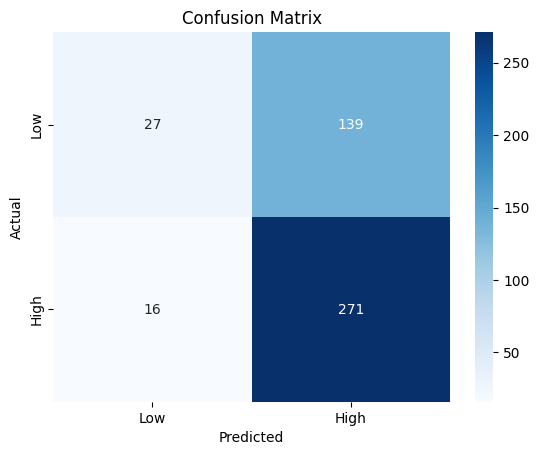

In [26]:

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### Adding sentiment

In [27]:
from scipy.sparse import hstack

# Convert sentiment column to 2D array
sentiment_feature = df.loc[X_train.index, 'sentiment'].values.reshape(-1,1)
X_train_combined = hstack([X_train_vectorized, sentiment_feature])

sentiment_feature_test = df.loc[X_test.index, 'sentiment'].values.reshape(-1,1)
X_test_combined = hstack([X_test_vectorized, sentiment_feature_test])

# Retrain classifier
classifier.fit(X_train_combined, y_train)
predictions = classifier.predict(X_test_combined)

print(classification_report(y_test, predictions))
print("Accuracy with sentiment feature:", accuracy_score(y_test, predictions))


              precision    recall  f1-score   support

           0       0.65      0.14      0.24       166
           1       0.66      0.95      0.78       287

    accuracy                           0.66       453
   macro avg       0.65      0.55      0.51       453
weighted avg       0.65      0.66      0.58       453

Accuracy with sentiment feature: 0.6578366445916115


The model predicts correctly about 69% of the time, which is very similar to the previous model. A recall of 0.94 means that most high-rating movies are correctly identified, and there is a good balance between precision and recall, capturing the majority of true positives while maintaining moderate false positives (F1-score = 0.8).
Recall for lower rating movies still performs poorly (recall = 0.22) as the model is missing 78% of low-rating movies. The balance (F1-score 0.33) between precision and recall is also week, reinforcing that the model struggles with minority/low-rating instances.


Macro F1 0.56 indicates poor overall performance when treating classes equally, and Weighted F1 0.63 shows an inflated/preference towards the majority class (high ratings), similar to the previous report.


As accuracy barely changes, it suggests that adding sentiment features did not significantly improve overall prediction accuracy. Performance on the majority class remains strong, while the minority class is still poorly predicted, indicating persistent class imbalance issues. The model continues to heavily favor high-rating movies. While sentiment features may slightly influence predictions, they do not address the fundamental issue of low recall for low-rating movies, highlighting a need for resampling, class weighting, or alternative evaluation metrics to better capture minority classes.

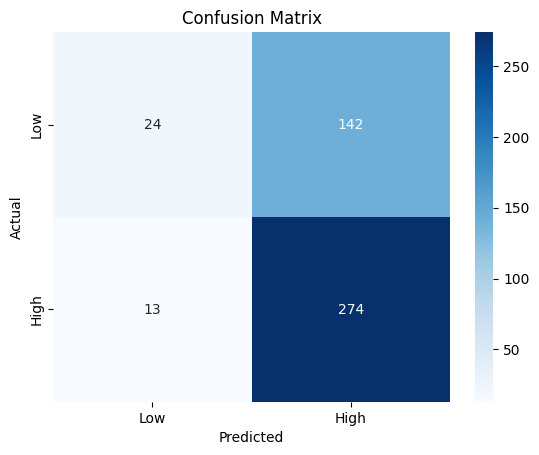

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [29]:

misclassified = df.loc[X_test.index][predictions != y_test]
misclassified[['Comment', 'rating_class','sentiment']].reset_index()

,index,Comment,rating_class,sentiment
0,382,"Moment of breath, a small pause in the noise, ...",0,0.4580
1,583,"""When I said I wished I was with you, I didn't...",0,0.9932
2,705,Didn’t have anything to say about this until I...,0,-0.7274
3,868,Two Germans running off to Peru to find the lo...,0,-0.5106
4,1120,"First time watching one of these weird, copyri...",0,-0.9294
...,...,...,...,...
150,1178,undeniably funny that this 160-minute half-mov...,0,-0.4588
151,355,“i can fix him” says girl who is worse,0,-0.4767
152,849,Dorothy in the Taylor Swift Showgirl Collectio...,0,0.5719
153,777,"This is completely unrelated to the film, but ...",0,0.9858


After reformulating the problem as binary classification (High ≥4.0 stars vs. Low <4.0 stars), the Random Forest classifier achieved 64.5% accuracy for Text-only model and 65.3% accuracy for text + sentiment feature model. While this is a substantial improvement over the 25% accuracy of multi-class prediction, it is not great.

The model has a strong bias toward predicting "High". It correctly identifies most high-rated reviews (94% recall for class 1) but struggles to identify low-rated reviews (only 16% recall for class 0). In other words, the model defaults to guessing "high rating" because that's the dominant pattern in the data. Even with sentiment model, there's minimal improvement. The mode is slightly better at identifying low ratings, but it still heavily biased toward predicting "High"

In this notebook, the model somewhat predict ratings from review text, but not reliably. The 64-65% accuracy tells us that there is some signal linking language to ratings as the model performs better than random chance (50%), indicating that certain words and phrases do correlate with high vs. low ratings. However it is weak as 35% of predictions are still wrong, and the odel frequently misclassifies low-rated reviews as high because class imblance. Other potential reasonings may be because users write reviews to entertain and perform, not just evaluate. A review full of emotional language might receive any rating depending on context, sarcasm, or personal taste. Also, both positive and negative reviews may discuss the same topics (plot, acting, cinematography) using similar language, making them hard to distinguish

Because VADER sentiment scores improves accuracy by less than 1%, it reinforces our earlier finding that automated sentiment analysis captures almost nothing useful about how users actually rate films. If sentiment were a strong predictor of ratings, we'd expect a much larger improvement.


This classification task demonstrates that machine learning can identify broad patterns but cannot reliably navigate the complexity, irony, and performativity of contemporary online discourse.

We can predict ratings from text with moderate success when language is literal, but the model fails whenever users prioritise entertainment, humour, or cultural performance over straightforward evaluation. This is not a limitation of Random Forest specifically, but it's a  challenge of applying algorithmic pattern-matching to human communication that is inherently context-dependent and socially performed.